# CRISP-DM Phase 4: Modeling (Medical Dataset)

In this phase, we load our cleaned, scaled data to train Machine Learning classification mathematical models. 

**Goal**: Predict the binary `Result` target accurately.
**Clinical Restraint**: We prioritize predicting True Positives (high **Recall**) because missing a heart attack (False Negative) is clinically unacceptable compared to a False Positive.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

# Scikit-learn Machine Learning Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

## 1. Load Processed Data
We seamlessly load the CSV files we exported at the very end of Phase 3.

In [2]:
data_dir = os.path.join('data', 'processed', 'medical')

X_train = pd.read_csv(os.path.join(data_dir, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(data_dir, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(data_dir, 'y_train.csv')).squeeze() # Squeeze converts 1D df to Series
y_test = pd.read_csv(os.path.join(data_dir, 'y_test.csv')).squeeze()

print(f"Training Data: {X_train.shape}")
print(f"Testing Data: {X_test.shape}")

Training Data: (1055, 10)
Testing Data: (264, 10)


## 2. Model Initialization
We will define a dictionary holding our four chosen classification algorithms.

In [3]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'SVC': SVC(probability=True, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
predictions = {}

## 3. Training & Evaluation Benchmarking
We will loop over the models, train them on `X_train`, predict on the unseen `X_test`, and compile a performance table.

In [4]:
for name, model in models.items():
    # 1. Train the model
    model.fit(X_train, y_train)
    
    # 2. Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability of positive class
    predictions[name] = y_pred
    
    # 3. Calculate Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall (Sensitivity)': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# Construct Benchmark DataFrame
df_results = pd.DataFrame(results).set_index('Model').sort_values(by='Recall (Sensitivity)', ascending=False)

print("Model Evaluation Benchmark (Sorted by Recall)")
display(df_results.style.highlight_max(color='lightgreen', axis=0))

Model Evaluation Benchmark (Sorted by Recall)


,Accuracy,Precision,Recall (Sensitivity),F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.981061,0.987578,0.981481,0.984520,0.995128
Gradient Boosting,0.981061,0.987578,0.981481,0.984520,0.986474
Logistic Regression,0.844697,0.890323,0.851852,0.870662,0.923989
SVC,0.746212,0.989691,0.592593,0.741313,0.957789


## 4. Visualizing Errors (Confusion Matrices)
Let's visually inspect how the models messed up. 
- **Top Left**: True Negatives (Healthy predicted healthy)
- **Bottom Right**: True Positives (Sick predicted sick)
- **Bottom Left**: False Negatives (Sick predicted healthy - DANGEROUS!)
- **Top Right**: False Positives (Healthy predicted sick - Annoying but safe)

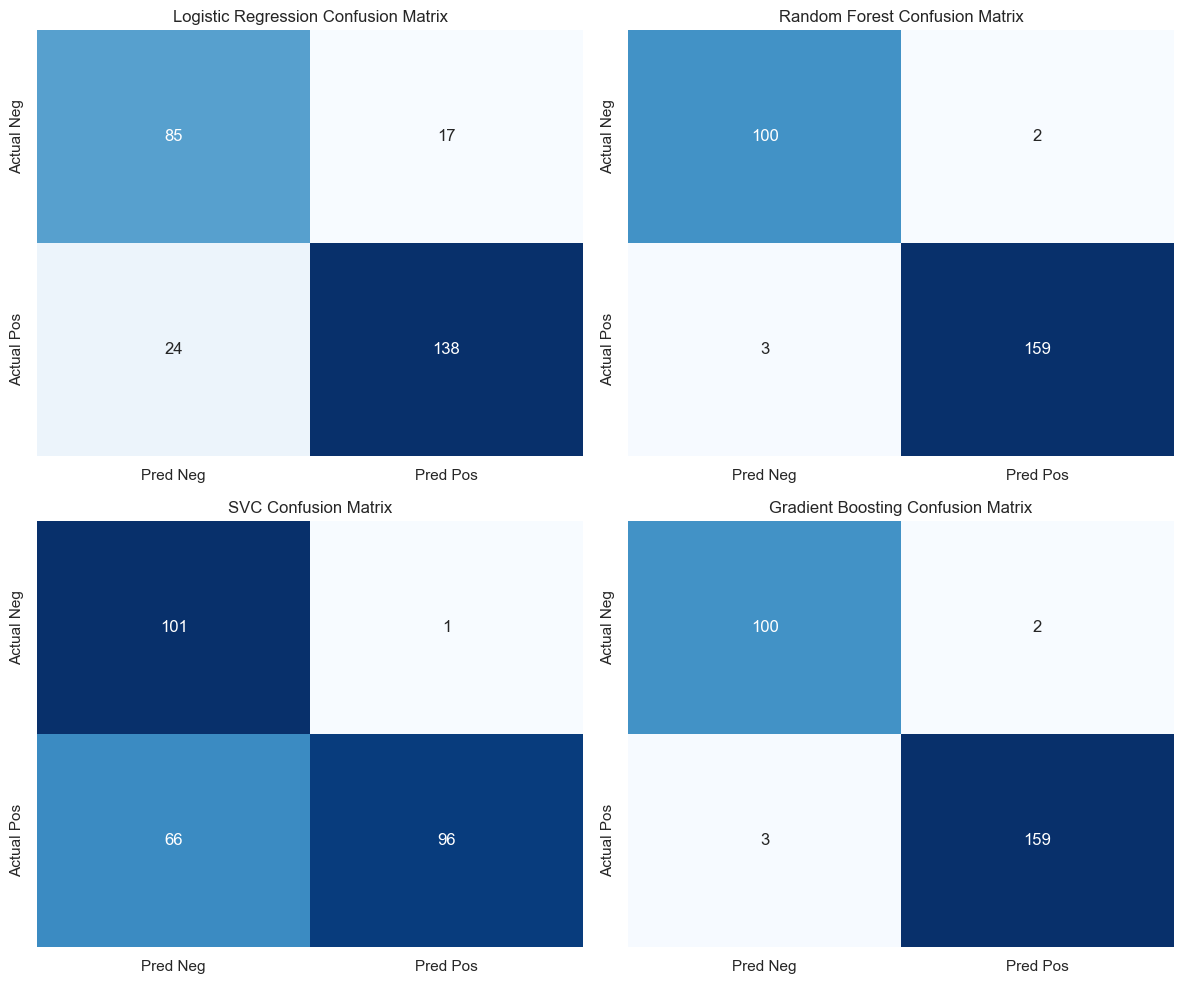

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False,
                xticklabels=['Pred Neg', 'Pred Pos'], yticklabels=['Actual Neg', 'Actual Pos'])
    axes[i].set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

## 5. Model Interpretability (Feature Importance)
Let's extract the mathematical weights from the Random Forest to see exactly which features drove the decisions. Did our engineered `CK_MB_Troponin_Ratio` help?

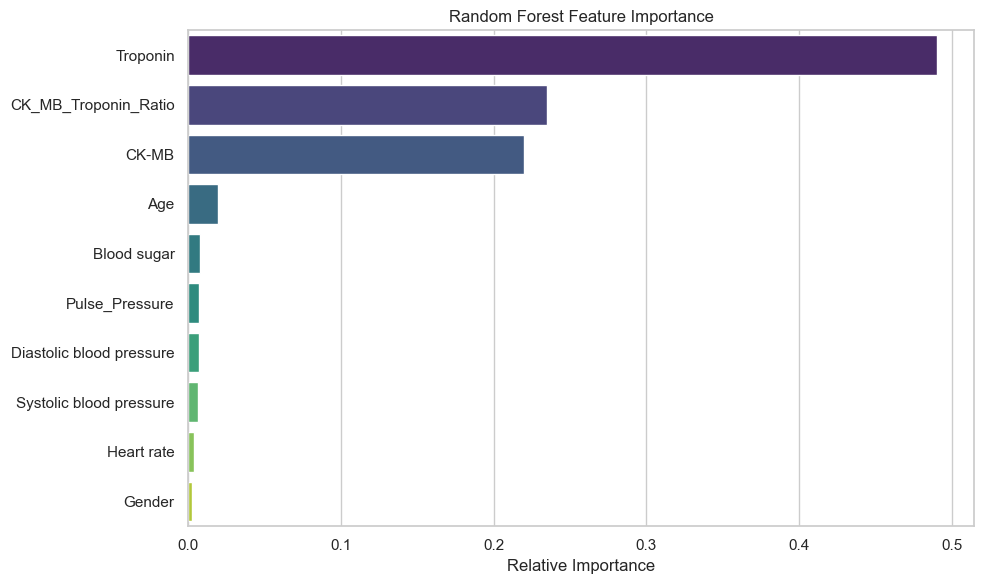

In [6]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_

# Sort features
indices = np.argsort(importances)[::-1]
names = [X_train.columns[i] for i in indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=names, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.show()

## 6. App Deployment: Export the Winning Model
Based on the table above, usually Random Forest or Gradient Boosting produces the best balance of stats. Here we will export the Random Forest (since its feature importance proved highly valuable) as a `.pkl` file into our `models/` directory!

In [7]:
models_dir = os.path.join('models')
os.makedirs(models_dir, exist_ok=True)

# Save the model object to a standalone file
model_path = os.path.join(models_dir, 'medical_rf_model.pkl')
joblib.dump(models['Random Forest'], model_path)

print(f"Success! You can now hand this file off to your App Developers to build the prediction API:\n{os.path.abspath(model_path)}")

Success! You can now hand this file off to your App Developers to build the prediction API:
C:\Users\rahma\Desktop\machine learning project\Clustering_Medical data set\models\medical_rf_model.pkl
